In [5]:
#import model_definition as mdef
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# test import of h5 chip:
h5_file = h5py.File('/new_emit_dataset_vol/just_hypercubes/20230403T111207/chip_0.h5', 'r')

h5_file 

<HDF5 file "chip_0.h5" (mode r)>

In [7]:
#convert h5 to numpy array:
h5_array = np.array(h5_file['hypercube'])
h5_array.shape

(128, 128, 285)

In [9]:
#rotate axes of array to be C, H, W:
h5_array = np.transpose(h5_array, (2, 1, 0))
h5_array.shape


(285, 128, 128)

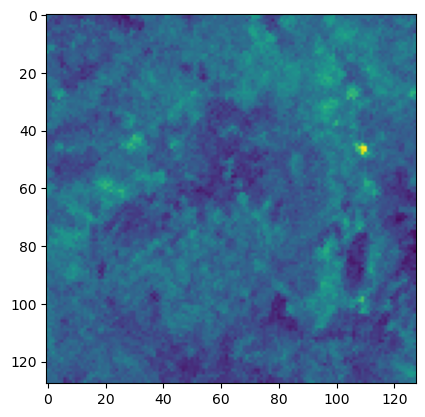

In [14]:
# plot first channel of the array:
plt.imshow(h5_array[0, :, :])

In [2]:
import model_definition as m
import torch
model = m.SimpleHyperspectralMAEEncoder()
x = torch.randn(2, 128, 128, 285)
loss = model(x)
loss.backward()

In [ ]:
# Visual reconstruction — GT must be raw chip (H,W,C), not unpatchify before the patchify fix
import importlib
importlib.reload(m)

chip_hwc = np.array(h5_file["hypercube"], dtype=np.float32)  # (128, 128, 285)
batch = torch.from_numpy(chip_hwc).unsqueeze(0).to(device)

model.eval()
torch.manual_seed(0)
pred_hwc, _ = model.reconstruct(batch)
pred_np = pred_hwc[0].cpu().numpy()

band_idx = 140
vmin = np.percentile(chip_hwc[:, :, band_idx], 2)
vmax = np.percentile(chip_hwc[:, :, band_idx], 98)
err_np = np.abs(pred_np - chip_hwc)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(chip_hwc[:, :, band_idx], cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title(f"GT band {band_idx} (raw chip)")
axes[1].imshow(pred_np[:, :, band_idx], cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstruction")
axes[2].imshow(err_np[:, :, band_idx], cmap="hot")
axes[2].set_title("|error|")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# sanity: patchify roundtrip should be exact
rt_err = (model.unpatchify(model.patchify(batch))[0].cpu().numpy() - chip_hwc).max()
print("patchify roundtrip max |err|:", rt_err)
print("holistic MSE:", np.mean((pred_np - chip_hwc) ** 2))

# Initial Run + Intentional Overfitting to check convergence

In [3]:
import torch
import model_definition as m

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = m.SimpleHyperspectralMAEEncoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [8]:
# h5 'hypercube' is (H, W, C) = (128, 128, 285)
chip_hwc = np.array(h5_file["hypercube"], dtype=np.float32)
print("chip shape (H, W, C):", chip_hwc.shape)

batch = torch.from_numpy(chip_hwc).unsqueeze(0).to(device)  # (1, 128, 128, 285)
print("batch shape:", batch.shape)

chip shape (H, W, C): (128, 128, 285)
batch shape: torch.Size([1, 128, 128, 285])


In [9]:
model.zero_grad(set_to_none=True)
loss = model(batch)
print("loss:", loss.item())
loss.backward()
optimizer.step()
print("backward OK")

loss: 18.062408447265625
backward OK


step    1  loss 17.575140
step   50  loss 9.816612
step  100  loss 8.876009
step  150  loss 8.555034
step  200  loss 8.224629
step  250  loss 7.946800
step  300  loss 7.805117
step  350  loss 7.650034
step  400  loss 7.550380
step  450  loss 7.422579
step  500  loss 7.390450
step  550  loss 7.296000
step  600  loss 7.222711
step  650  loss 7.195343
step  700  loss 7.144400
step  750  loss 7.113734
step  800  loss 7.008801
step  850  loss 7.008136
step  900  loss 7.030695
step  950  loss 6.977285
step 1000  loss 6.913777


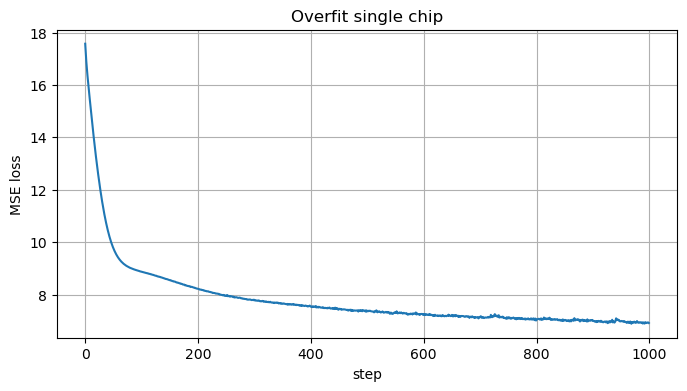

In [10]:
num_steps = 1000
log_every = 50
loss_history = []

model.train()
for step in range(1, num_steps + 1):
    model.zero_grad(set_to_none=True)
    loss = model(batch)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if step % log_every == 0 or step == 1:
        print(f"step {step:4d}  loss {loss.item():.6f}")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("Overfit single chip")
plt.grid(True)
plt.show()

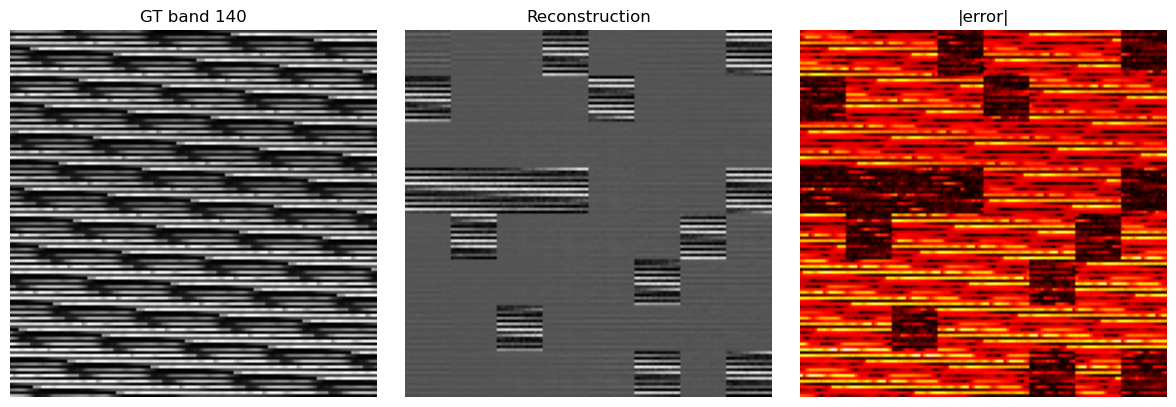

holistic MSE (numpy): 6.892959


In [11]:
@torch.no_grad()
def reconstruct(batch):
    model.eval()
    batch_size = batch.shape[0]

    x = batch.reshape(
        batch_size,
        model.num_patches_c,
        model.patch_size_spectral,
        model.num_patches_h,
        model.patch_size_spatial,
        model.num_patches_w,
        model.patch_size_spatial,
    )
    x = x.permute(0, 1, 3, 5, 2, 4, 6)
    patches = x.reshape(batch_size, model.num_tokens, model.patch_volume)
    tokens = model.patch_embed_3d_linear(patches) + model.pos_embed.unsqueeze(0)

    shuffle = torch.rand(batch_size, model.num_tokens, device=tokens.device).argsort(dim=1)
    len_visible = int(model.num_tokens * (1.0 - model.masking_ratio))
    ids_visible = shuffle[:, :len_visible]

    encoder_in = torch.gather(
        tokens, 1, ids_visible.unsqueeze(-1).expand(-1, -1, model.encoder_embed_dim)
    )
    encoder_out = model.encoder(encoder_in)

    decoder_in = model.mask_token.expand(batch_size, model.num_tokens, model.encoder_embed_dim).clone()
    decoder_in.scatter_(
        1, ids_visible.unsqueeze(-1).expand(-1, -1, model.encoder_embed_dim), encoder_out
    )
    decoder_in = decoder_in + model.pos_embed.unsqueeze(0)
    pred_patches = model.pred_head(model.decoder(decoder_in))

    def unpatchify(p):
        p = p.reshape(
            batch_size,
            model.num_patches_c,
            model.num_patches_h,
            model.num_patches_w,
            model.patch_size_spectral,
            model.patch_size_spatial,
            model.patch_size_spatial,
        )
        p = p.permute(0, 1, 4, 2, 5, 3, 6)
        p = p.reshape(batch_size, model.num_bands, model.chip_size_spatial, model.chip_size_spatial)
        return p.permute(0, 2, 3, 1)

    return unpatchify(pred_patches), unpatchify(patches)


torch.manual_seed(0)
pred, target = reconstruct(batch)
pred_np = pred[0].cpu().numpy()
target_np = target[0].cpu().numpy()
err_np = np.abs(pred_np - target_np)

band_idx = 140
vmin = np.percentile(target_np[:, :, band_idx], 2)
vmax = np.percentile(target_np[:, :, band_idx], 98)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_np[:, :, band_idx], cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title(f"GT band {band_idx}")
axes[1].imshow(pred_np[:, :, band_idx], cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstruction")
axes[2].imshow(err_np[:, :, band_idx], cmap="hot")
axes[2].set_title("|error|")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

band_mse = np.mean((pred_np - target_np) ** 2)
print(f"holistic MSE (numpy): {band_mse:.6f}")